# Assignment 4 - LSTM-based model for time-series forecasting
**Topic:** 2026-27 - TY E2 - DL Lab
**Description:** Develop an LSTM-based model for time-series forecasting using stock-price, weather or sales datasets.

## 1. Import Necessary Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM, Dropout
import math
from sklearn.metrics import mean_squared_error

## 2. Load and Preprocess Data
We will use a synthetic stock price dataset for demonstration, which mimics a sine wave with some noise.

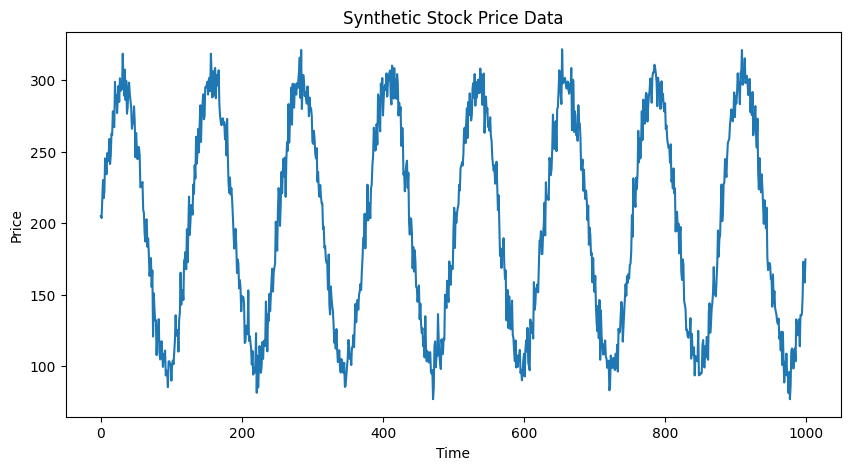

In [2]:
np.random.seed(42)
time_steps = 1000
time = np.arange(time_steps)
prices = np.sin(time * 0.05) * 100 + 200 + np.random.normal(scale=10, size=time_steps)

df = pd.DataFrame({'Price': prices})
plt.figure(figsize=(10, 5))
plt.plot(df['Price'])
plt.title('Synthetic Stock Price Data')
plt.xlabel('Time')
plt.ylabel('Price')
plt.show()

In [3]:
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(df['Price'].values.reshape(-1, 1))

training_data_len = int(np.ceil(len(scaled_data) * .8))
train_data = scaled_data[0:int(training_data_len), :]
test_data = scaled_data[training_data_len - 60:, :]

## 3. Create Sequences for LSTM

In [4]:
def create_sequences(data, seq_length):
    X, y = [], []
    for i in range(seq_length, len(data)):
        X.append(data[i-seq_length:i, 0])
        y.append(data[i, 0])
    return np.array(X), np.array(y)

seq_length = 60
X_train, y_train = create_sequences(train_data, seq_length)
X_train = np.reshape(X_train, (X_train.shape[0], X_train.shape[1], 1))

X_test, y_test = create_sequences(test_data, seq_length)
X_test = np.reshape(X_test, (X_test.shape[0], X_test.shape[1], 1))

## 4. Build the LSTM Model

In [5]:
model = Sequential()
model.add(LSTM(50, return_sequences=True, input_shape=(X_train.shape[1], 1)))
model.add(LSTM(50, return_sequences=False))
model.add(Dense(25))
model.add(Dense(1))

model.compile(optimizer='adam', loss='mean_squared_error')
model.summary()

c:\Users\Lenovo\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 60, 50)         │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 50)             │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 25)             │         1,275 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            26 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 31,901 (124.61 KB)

 Trainable params: 31,901 (124.61 KB)

 Non-trainable params: 0 (0.00 B)

## 5. Train the Model

In [6]:
history = model.fit(X_train, y_train, batch_size=32, epochs=10, validation_split=0.1)

Epoch 1/10
21/21 ━━━━━━━━━━━━━━━━━━━━ 7s 72ms/step - loss: 0.0638 - val_loss: 0.0279
Epoch 2/10
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 41ms/step - loss: 0.0120 - val_loss: 0.0072
Epoch 3/10
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - loss: 0.0034 - val_loss: 0.0020
Epoch 4/10
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 43ms/step - loss: 0.0021 - val_loss: 0.0018
Epoch 5/10
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step - loss: 0.0020 - val_loss: 0.0018
Epoch 6/10
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - loss: 0.0020 - val_loss: 0.0018
Epoch 7/10
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step - loss: 0.0019 - val_loss: 0.0021
Epoch 8/10
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - loss: 0.0022 - val_loss: 0.0019
Epoch 9/10
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - loss: 0.0020 - val_loss: 0.0019
Epoch 10/10
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 42ms/step - loss: 0.0021 - val_loss: 0.0019


## 6. Evaluate and Visualize Results

7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 101ms/step
Root Mean Squared Error: 10.51483329954607


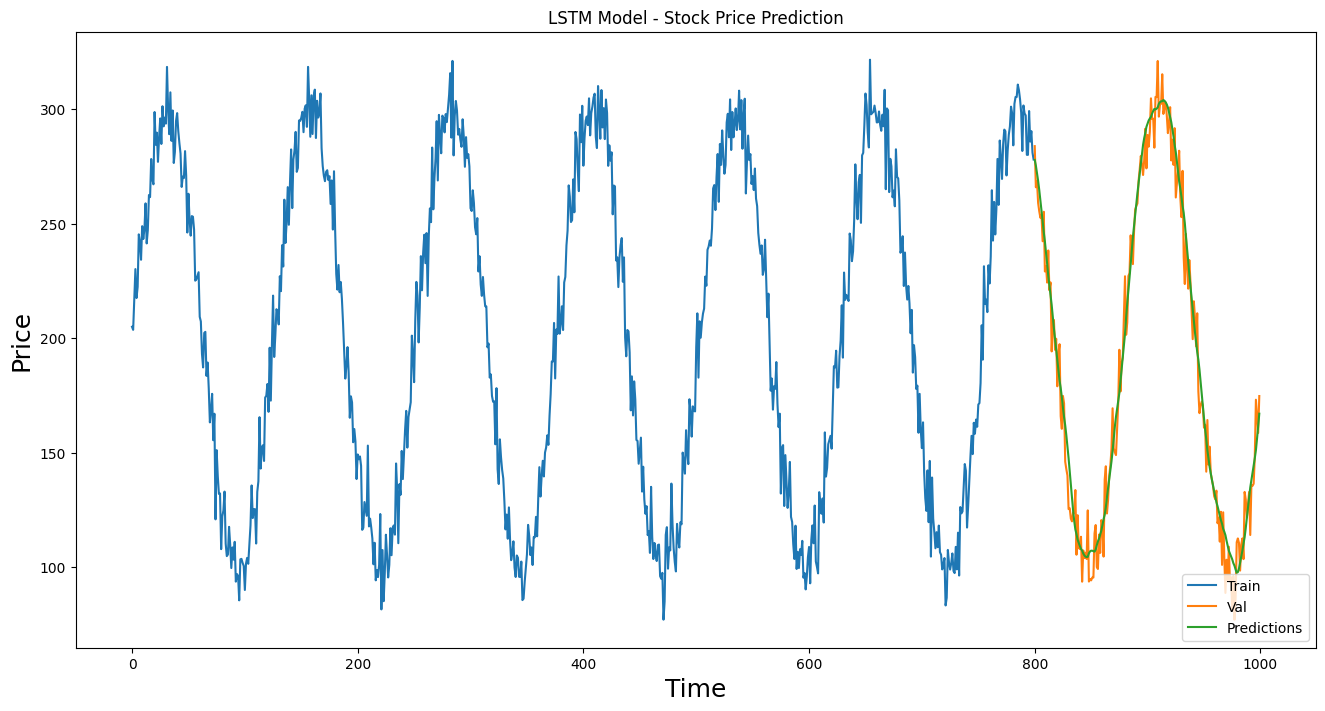

In [7]:
predictions = model.predict(X_test)
predictions = scaler.inverse_transform(predictions)

y_test_scaled = scaler.inverse_transform(y_test.reshape(-1, 1))
rmse = np.sqrt(np.mean(((predictions - y_test_scaled) ** 2)))
print(f'Root Mean Squared Error: {rmse}')

train = df[:training_data_len]
valid = df[training_data_len:].copy()
valid['Predictions'] = predictions

plt.figure(figsize=(16,8))
plt.title('LSTM Model - Stock Price Prediction')
plt.xlabel('Time', fontsize=18)
plt.ylabel('Price', fontsize=18)
plt.plot(train['Price'])
plt.plot(valid[['Price', 'Predictions']])
plt.legend(['Train', 'Val', 'Predictions'], loc='lower right')
plt.show()